# Gradient Boosted Survival Model
**In this notebook, we'll train and test a gradient boosting survival model from scikit-learn to predict 6 month survival from time of first line treatment of chemo-only for metastatic colorectal cancer.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc

import matplotlib.pyplot as plt

from utils.cv_predictions import cross_validated_survival_predictions

## Import

In [2]:
dtype_map = pd.read_csv('../outputs/1L_features_chemo_training_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
train_df = pd.read_csv('../outputs/1L_features_chemo_training.csv', dtype = dtype_map)
train_df.shape

(20626, 162)

In [3]:
dtype_map = pd.read_csv('../outputs/1L_features_chemo_testing_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
test_df = pd.read_csv('../outputs/1L_features_chemo_testing.csv', dtype = dtype_map)
test_df.shape

(5156, 162)

In [4]:
censored_before_6m = (len(train_df.query('event == 0 and duration < 180', engine = 'python'))/len(train_df))*100
censored_before_12m = (len(train_df.query('event == 0 and duration < 365', engine = 'python'))/len(train_df))*100

print(f'Percentage censored before 6 months: {round(censored_before_6m, 1)}%')
print(f'Percentage censored before 12 months: {round(censored_before_12m, 1)}%')

Percentage censored before 6 months: 5.9%
Percentage censored before 12 months: 10.5%


## Preprocess

### Selecting features

#### Categorical variables

In [5]:
list(train_df.select_dtypes(include = ['category']).columns)

['CrcSite',
 'met_diagnosis_year',
 'Ethnicity_mod',
 'Race_mod',
 'region',
 'BRAF_status',
 'KRAS_status',
 'NRAS_status',
 'MMR/MSI_status',
 'HER2_status',
 'HER2_percent_staining']

In [6]:
# Percent unknown
var_dict = {}
for var in train_df.select_dtypes(include=['category']).columns:
    value_props = train_df[var].value_counts(normalize=True)
    # Combine 'unknown' and 'Unknown' if both exist
    unknown_pct = value_props.get('unknown', 0) + value_props.get('Unknown', 0) + value_props.get('Unknown/Not documented', 0)
    var_dict[var] = round(unknown_pct*100, 3)

var_dict

{'CrcSite': 0,
 'met_diagnosis_year': 0,
 'Ethnicity_mod': 0,
 'Race_mod': 0,
 'region': np.float64(22.937),
 'BRAF_status': np.float64(49.307),
 'KRAS_status': np.float64(36.478),
 'NRAS_status': np.float64(51.828),
 'MMR/MSI_status': np.float64(34.166),
 'HER2_status': np.float64(70.426),
 'HER2_percent_staining': np.float64(99.874)}

In [7]:
# Percent positive
var_dict = {}
for var in train_df.select_dtypes(include=['category']).columns.drop(['CrcSite', 'met_diagnosis_year', 'Ethnicity_mod', 'Race_mod', 'region', 'HER2_percent_staining']):
    value_props = train_df[var].value_counts(normalize=True)
    pos_pct = value_props.get('positive', 0) + value_props.get('Positive', 0) 
    var_dict[var] = round(pos_pct*100, 3)

var_dict

{'BRAF_status': np.float64(5.018),
 'KRAS_status': np.float64(32.512),
 'NRAS_status': np.float64(2.254),
 'MMR/MSI_status': np.float64(2.982),
 'HER2_status': np.float64(1.779)}

In [8]:
categorical_var = [
    'CrcSite', 
    'BRAF_status',
    'KRAS_status',
    'NRAS_status',
    'MMR/MSI_status', 
    'HER2_status'
]

#### Binary variables 

In [9]:
list(train_df.select_dtypes(include = ['int']).columns)

['days_met_to_treatment',
 'GroupStage_mod_na',
 'age',
 'sex_male',
 'ecog_newly_gte2',
 'ecog_index_na',
 'hypotension',
 'tachycardia',
 'fevers',
 'hypoxemia',
 'anticoagulant',
 'opioid',
 'steroid',
 'antibiotic',
 'diabetic_med',
 'antidepressant',
 'bone_therapy_agent',
 'immunosuppressant',
 'chf',
 'cardiac_arrhythmias',
 'valvular_disease',
 'pulm_circulation',
 'pvd',
 'htn_uncomplicated',
 'htn_complicated',
 'paralysis',
 'other_neuro',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'pud',
 'aids_hiv',
 'lymphoma',
 'rheumatic',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'blood_loss_anemia',
 'deficiency_anemia',
 'alcohol_abuse',
 'drug_abuse',
 'psychoses',
 'depression',
 'van_walraven_score',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'brain_met',
 'adrenal_met',
 'peritoneum_met',
 'gi_met',
 'other_met',
 'event']

In [10]:
# Did not include days_met_to_treatment, age, van_walraven, or event
bin_list = [
    'GroupStage_mod_na',
    'sex_male',
    'ecog_newly_gte2',
    'ecog_index_na',
    'hypotension',
    'tachycardia',
    'fevers',
    'hypoxemia',
    'anticoagulant',
    'opioid',
    'steroid',
    'antibiotic',
    'diabetic_med',
    'antidepressant',
    'bone_therapy_agent',
    'immunosuppressant',
    'chf',
    'cardiac_arrhythmias',
    'valvular_disease',
    'pulm_circulation',
    'pvd',
    'htn_uncomplicated',
    'htn_complicated',
    'paralysis',
    'other_neuro',
    'chronic_pulm_disease',
    'diabetes_uncomplicated',
    'diabetes_complicated',
    'hypothyroid',
    'renal_failure',
    'liver_disease',
    'pud',
    'aids_hiv',
    'lymphoma',
    'rheumatic',
    'coagulopathy',
    'obesity',
    'weight_loss',
    'fluid',
    'blood_loss_anemia',
    'deficiency_anemia',
    'alcohol_abuse',
    'drug_abuse',
    'psychoses',
    'depression',
    'lymph_met',
    'thoracic_met',
    'liver_met',
    'bone_met',
    'brain_met',
    'adrenal_met',
    'peritoneum_met',
    'gi_met',
    'other_met'
]

In [11]:
# Identify binary variables with >3% prevalence 
bin_var_list = []
for bin_var in bin_list:
    if (train_df[bin_var].value_counts(normalize = True)[1] >= 0.03):
        bin_var_list.append(bin_var)

In [12]:
bin_var_list

['sex_male',
 'ecog_index_na',
 'tachycardia',
 'opioid',
 'steroid',
 'antibiotic',
 'cardiac_arrhythmias',
 'htn_uncomplicated',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'blood_loss_anemia',
 'deficiency_anemia',
 'depression',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'peritoneum_met',
 'other_met']

In [13]:
# GroupStage_mod_na and ecog_index_na added as flags later
binary_var = [
    'sex_male',
    'tachycardia',
    'opioid',
    'steroid',
    'antibiotic',
    'cardiac_arrhythmias',
    'htn_uncomplicated',
    'chronic_pulm_disease',
    'diabetes_uncomplicated',
    'diabetes_complicated',
    'hypothyroid',
    'renal_failure',
    'liver_disease',
    'coagulopathy',
    'obesity',
    'weight_loss',
    'fluid',
    'blood_loss_anemia',
    'deficiency_anemia',
    'depression',
    'lymph_met',
    'thoracic_met',
    'liver_met',
    'peritoneum_met',
    'other_met'
]

#### Numerical variables

In [14]:
list(train_df.select_dtypes(include = ['float64']).columns)

['GroupStage_mod',
 'days_diagnosis_to_met',
 'ecog_index',
 'weight_index',
 'bmi_index',
 'percent_change_weight',
 'albumin',
 'alp',
 'alt',
 'ast',
 'bicarbonate',
 'bun',
 'calcium',
 'cea',
 'chloride',
 'creatinine',
 'hemoglobin',
 'ldh',
 'platelet',
 'potassium',
 'sodium',
 'total_bilirubin',
 'wbc',
 'albumin_max',
 'alp_max',
 'alt_max',
 'ast_max',
 'bicarbonate_max',
 'bun_max',
 'calcium_max',
 'cea_max',
 'chloride_max',
 'creatinine_max',
 'hemoglobin_max',
 'ldh_max',
 'platelet_max',
 'potassium_max',
 'sodium_max',
 'total_bilirubin_max',
 'wbc_max',
 'albumin_min',
 'alp_min',
 'alt_min',
 'ast_min',
 'bicarbonate_min',
 'bun_min',
 'calcium_min',
 'cea_min',
 'chloride_min',
 'creatinine_min',
 'hemoglobin_min',
 'ldh_min',
 'platelet_min',
 'potassium_min',
 'sodium_min',
 'total_bilirubin_min',
 'wbc_min',
 'albumin_std',
 'alp_std',
 'alt_std',
 'ast_std',
 'bicarbonate_std',
 'bun_std',
 'calcium_std',
 'cea_std',
 'chloride_std',
 'creatinine_std',
 'hemogl

In [15]:
# Added age, van_walraven_score, and days_met_to_treatment here 
numerical_var = [
    'GroupStage_mod',
    'days_diagnosis_to_met',
    'ecog_index',
    'weight_index',
    'bmi_index',
    'percent_change_weight',
    'albumin',
    'alp',
    'alt',
    'ast',
    'bicarbonate',
    'bun',
    'calcium',
    'cea',
    'chloride',
    'creatinine',
    'hemoglobin',
    'platelet',
    'potassium',
    'sodium',
    'total_bilirubin',
    'wbc',
    'alp_max',
    'alt_max',
    'ast_max',
    'calcium_max',
    'cea_max',
    'creatinine_max',
    'platelet_max',
    'potassium_max',
    'sodium_max',
    'total_bilirubin_max',
    'wbc_max',
    'albumin_min',
    'bicarbonate_min',
    'calcium_min',
    'hemoglobin_min',
    'platelet_min',
    'potassium_min',
    'sodium_min',
    'age',
    'van_walraven_score',
    'days_met_to_treatment'
]

In [16]:
all_var = categorical_var + binary_var + numerical_var

In [17]:
missing = train_df[all_var].isnull().sum()
missing[missing > 0].sort_values(ascending = False)

van_walraven_score       8616
cea                      5853
cea_max                  5479
chloride                 4087
albumin                  3666
albumin_min              3499
calcium                  3402
total_bilirubin          3382
bicarbonate              3367
alt                      3320
ast                      3261
alp                      3251
calcium_max              3237
calcium_min              3237
total_bilirubin_max      3211
bicarbonate_min          3210
potassium                3200
sodium                   3167
alt_max                  3140
ast_max                  3083
alp_max                  3072
potassium_max            3036
potassium_min            3036
bun                      3033
sodium_min               3003
sodium_max               3003
creatinine               2944
creatinine_max           2783
wbc                      1744
hemoglobin               1743
platelet                 1732
wbc_max                  1652
hemoglobin_min           1650
percent_ch

In [18]:
# Create a missing flag
for x in missing[missing > 0].index:
    train_df[f'{x}_na'] = np.where(train_df[x].isna(), 1, 0)
    test_df[f'{x}_na'] = np.where(test_df[x].isna(), 1, 0)

In [19]:
# Add missing flags to binary_var (this includes ecog_index_na and GroupStage_mod_na)
binary_var = binary_var + [col for col in train_df.columns if col.endswith('_na')]

In [20]:
all_var = categorical_var + binary_var + numerical_var

In [21]:
len(all_var)

114

### Setting up Y

In [22]:
y_dtype = [('event', bool), ('duration', float)]

In [23]:
# Death status and time until event needs to be stored as a structured array to be compatible with scikit-survival
train_y = np.array([tuple(x) for x in train_df[['event', 'duration']].values], 
                   dtype = y_dtype)

test_y = np.array([tuple(x) for x in test_df[['event', 'duration']].values], 
                  dtype = y_dtype)

### Creating pipeline

In [24]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median'))
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = "ignore", sparse_output = False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_var),
        ("cat", categorical_pipeline, categorical_var),
        ("pass", "passthrough", binary_var),
    ],
    remainder="drop"
)

## Train model

In [25]:
def six_month_auc_scorer_approximate(estimator, X, y):
    """
    Approximate 180d AUC using test set for censoring estimation.
    This is not ideal but may be acceptable if censoring is light (eg., <20%).
    """
    chf_funcs = estimator.predict_cumulative_hazard_function(X)
    risk_scores = np.array([chf(180) for chf in chf_funcs])
    
    # Use same y for both (not ideal, but functional)
    auc, _ = cumulative_dynamic_auc(y, y, risk_scores, 180)
    return auc[0]

auc_scorer = make_scorer(
    six_month_auc_scorer_approximate,
    greater_is_better = True,
    needs_proba = False  
)

param_distributions = {
    'model__n_estimators': [300, 500, 700],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.75, 0.85],
    'model__max_features': [0.7, 0.9]
}

gb = GradientBoostingSurvivalAnalysis(random_state = 42)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', gb)
])

search = RandomizedSearchCV(
    estimator = full_pipeline, 
    param_distributions = param_distributions, 
    n_iter = 15, 
    cv = 3,
    scoring = six_month_auc_scorer_approximate,
    refit = False,
    n_jobs = -1,
    random_state = 42,
    verbose = 1
)

search.fit(train_df[all_var], train_y)

print(f"Best params: {search.best_params_}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'model__subsample': 0.75, 'model__n_estimators': 700, 'model__max_features': 0.9, 'model__max_depth': 4, 'model__learning_rate': 0.05}


In [26]:
results_df = pd.DataFrame(search.cv_results_)
results_df.sort_values('rank_test_score', ascending = True).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__n_estimators,param_model__max_features,param_model__max_depth,param_model__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
7,1737.614218,8.930355,0.259423,0.003265,0.75,700,0.9,4,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.817644,0.765638,0.796688,0.793323,0.021364,1
4,1741.815833,36.902075,0.262258,0.025579,0.75,700,0.7,4,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.815951,0.764243,0.797421,0.792539,0.021390,2
10,1796.750295,11.868179,0.269626,0.036423,0.85,700,0.9,2,0.10,"{'model__subsample': 0.85, 'model__n_estimator...",0.814742,0.759870,0.797188,0.790600,0.022881,3
9,732.493974,4.164765,0.211264,0.007383,0.75,300,0.9,3,0.10,"{'model__subsample': 0.75, 'model__n_estimator...",0.813004,0.761365,0.795906,0.790092,0.021479,4
11,777.859921,5.245992,0.227819,0.020164,0.85,300,0.9,4,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.811667,0.762300,0.796253,0.790073,0.020622,5
1,1273.201792,20.676541,0.264027,0.015710,0.75,500,0.7,4,0.10,"{'model__subsample': 0.75, 'model__n_estimator...",0.811944,0.763159,0.794523,0.789876,0.020186,6
13,1240.434308,31.834038,0.184309,0.003437,0.85,500,0.9,2,0.10,"{'model__subsample': 0.85, 'model__n_estimator...",0.813727,0.758868,0.796551,0.789715,0.022912,7
14,1595.261520,8.896367,0.190238,0.001837,0.85,700,0.7,2,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.812491,0.759240,0.796006,0.789246,0.022259,8
0,1744.422538,21.272025,0.232833,0.009157,0.75,700,0.7,2,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.813378,0.757895,0.796212,0.789162,0.023193,9
5,1254.202379,23.908509,0.261871,0.016112,0.75,500,0.7,3,0.10,"{'model__subsample': 0.75, 'model__n_estimator...",0.811198,0.760114,0.795401,0.788905,0.021355,10


## Test model 

In [27]:
best_gb_model = GradientBoostingSurvivalAnalysis(
    n_estimators = 700,  
    learning_rate = 0.05,
    max_depth = 4,
    subsample = 0.75,
    max_features = 0.9,
    verbose = 1,
    random_state = 42
)

full_pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_gb_model)
])

full_pipeline_final.fit(train_df[all_var], train_y)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1       93110.4565          21.6084           59.53m
         2       93522.7128         427.7529           57.67m
         3       93268.7923        -148.1152           56.73m
         4       92855.2279        -293.2755           56.76m
         5       92955.3982         156.7520           56.37m
         6       93202.1567         273.2880           56.09m
         7       92961.5150        -147.4016           56.01m
         8       93083.7611         164.9484           55.81m
         9       92830.6932        -172.5467           55.68m
        10       92937.1947         160.3566           55.46m
        20       92563.8395         271.2259           53.76m
        30       91881.3374          50.0517           52.58m
        40       91788.2549          39.9260           51.58m
        50       91632.4273          83.5922           50.66m
        60       92005.2034         476.5257           49.78m
       

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['GroupStage_mod',
                                                   'days_diagnosis_to_met',
                                                   'ecog_index', 'weight_index',
                                                   'bmi_index',
                                                   'percent_change_weight',
                                                   'albumin', 'alp', 'alt',
                                                   'ast', 'bicarbonate', 'bun',
                                                   'calcium', 'cea', 'chloride',
                                                   'creatinine', 'hemoglobin',
                                                   'platelet...
                                                   'deficiency_anemia',
                                                   'depression', 'lymph_met',
                                                   'thoracic_met', 'liver_met',
                                                   'peritoneum_met',
                                                   'other_met',
                                                   'GroupStage_mod_na',
                                                   'ecog_index_na',
                                                   'weight_index_na',
                                                   'bmi_index_na',
                                                   'percent_change_weight_na', ...])])),
                ('model',
                 GradientBoostingSurvivalAnalysis(learning_rate=0.05,
                                                  max_depth=4, max_features=0.9,
                                                  n_estimators=700,
                                                  random_state=42,
                                                  subsample=0.75, verbose=1))])

### Evaluate performance on test and training set 

In [28]:
final_risk_scores_test = full_pipeline_final.predict(test_df[all_var])
final_auc_test = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, 180)[0][0]

print(f"Final 180-d AUC on Test Set: {final_auc_test:.3f}")

Final 180-d AUC on Test Set: 0.798


In [29]:
# Bootstrap 1000 180d AUCs for test set 
n_bootstraps = 1000
bootstrapped_scores_test = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_test), len(final_risk_scores_test))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        test_y[indices],
        final_risk_scores_test[indices],
        180
    )[0][0]
    bootstrapped_scores_test.append(auc_yr)

# Convert to array
bootstrapped_scores_test = np.array(bootstrapped_scores_test)

# Calculate 95% CI
conf_lower_test = np.percentile(bootstrapped_scores_test, 2.5)
conf_upper_test = np.percentile(bootstrapped_scores_test, 97.5)

In [30]:
final_risk_scores_train = full_pipeline_final.predict(train_df[all_var])
final_auc_train = cumulative_dynamic_auc(train_y, train_y, final_risk_scores_train, 180)[0][0]

print(f"Final 180-d AUC on Train Set: {final_auc_train:.3f}")

Final 180-d AUC on Train Set: 0.838


In [31]:
# Bootstrap 1000 180d AUCs for train set 
n_bootstraps = 1000
bootstrapped_scores_train = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_train), len(final_risk_scores_train))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        train_y[indices],
        final_risk_scores_train[indices],
        180
    )[0][0]
    bootstrapped_scores_train.append(auc_yr)

# Convert to array
bootstrapped_scores_train = np.array(bootstrapped_scores_train)

# Calculate 95% CI
conf_lower_train = np.percentile(bootstrapped_scores_train, 2.5)
conf_upper_train = np.percentile(bootstrapped_scores_train, 97.5)

In [32]:
# Define evaluation times
times = np.arange(30, 1810, 30)

# Calculate AUCs across times
gbm_auc_over5 = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, times)[0]

# Build a dictionary mapping 'time_x' -> AUC at that time
times_data = {f"time_{int(t)}": auc for t, auc in zip(times, gbm_auc_over5)}

# Create DataFrame
gbm_auc_over5_df = pd.DataFrame(times_data, index=['gbm'])

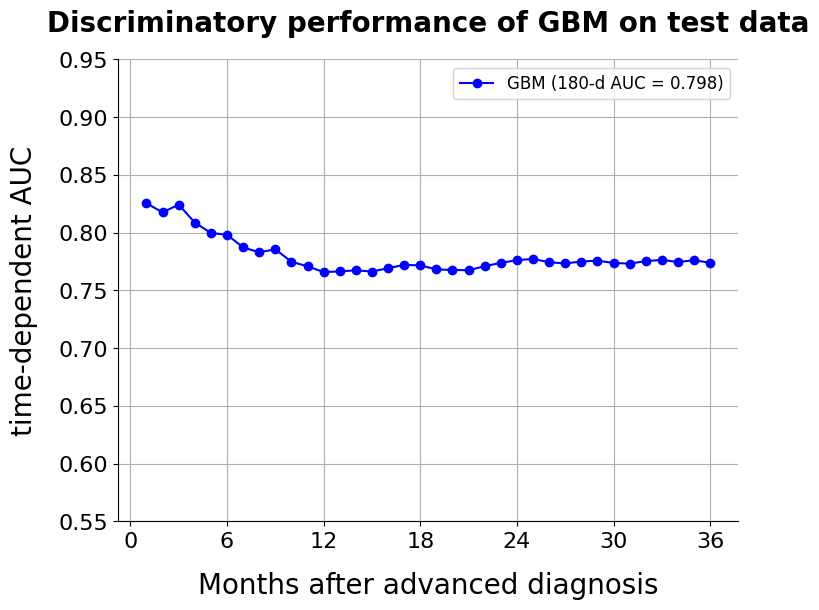

In [33]:
fig, ax0 = plt.subplots(figsize=(8, 6))

# Discriminatory performance plot
times = np.arange(30, 1095, 30)

ax0.plot(times/30, 
         gbm_auc_over5_df.loc['gbm'].values[0:36], 
         'o-', 
         color = 'blue', 
         label = f"GBM (180-d AUC = {final_auc_test:.3f})")

ax0.set_xticks(np.arange(0, 37, 6))
ax0.set_yticks(np.arange(0.55, 1.0, 0.05))
ax0.tick_params(axis = 'both', which = 'major', labelsize = 16) 

ax0.set_title('Discriminatory performance of GBM on test data', weight = 'bold', size = 20, pad = 20)
ax0.set_xlabel('Months after advanced diagnosis', labelpad = 15, size = 20)
ax0.set_ylabel('time-dependent AUC', labelpad = 15, size = 20)
ax0.legend(loc = 'upper right', prop = {'size': 12})
ax0.grid(True)

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

plt.show()

Total number of features: 114
Number of non-zero features in final model: 123


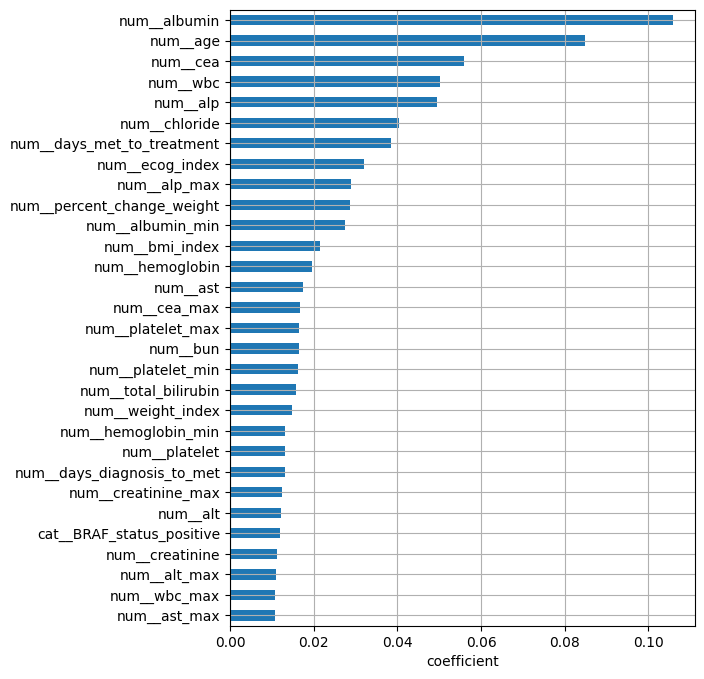

In [34]:
# Dataframe of coefficients for each variable 
gbm_feature_importance = pd.DataFrame(
    full_pipeline_final.named_steps['model'].feature_importances_,
    index = full_pipeline_final.named_steps['preprocessor'].get_feature_names_out(),
    columns = ['coefficient']
)

print('Total number of features: {}'.format(len(all_var)))

non_zero = np.sum(gbm_feature_importance.iloc[:, 0] != 0)
print('Number of non-zero features in final model: {}'.format(non_zero))

non_zero_coefs = gbm_feature_importance.query('coefficient != 0')
coef_order = non_zero_coefs.abs().sort_values('coefficient').tail(30).index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax = ax, legend = False)
ax.set_xlabel('coefficient')
ax.grid(True)

## Re-train on train and test df

In [35]:
df = pd.concat([train_df, test_df])

In [36]:
df.shape

(25782, 200)

In [37]:
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [38]:
best_gb_model = GradientBoostingSurvivalAnalysis(
    n_estimators = 700,  
    learning_rate = 0.05,
    max_depth = 4,
    subsample = 0.75,
    max_features = 0.9,
    verbose = 1,
    random_state = 42
)

full_pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_gb_model)
])

full_pipeline_final.fit(df[all_var], y)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1      119380.8167          26.6553           87.72m
         2      119735.1625         396.8503           87.12m
         3      119358.2584        -241.9980           86.86m
         4      119710.0550         391.1556           86.79m
         5      119114.1223        -437.6650           86.74m
         6      119193.1297         150.3342           86.50m
         7      119257.9346         131.0509           86.30m
         8      118853.4790        -280.9324           86.12m
         9      118646.3606        -112.7143           85.96m
        10      118703.3121         119.3188           85.78m
        20      118700.7313         603.2875           83.88m
        30      118335.9249         244.6072           82.31m
        40      117568.2250        -644.4154           81.16m
        50      117450.7444        -258.0979           79.75m
        60      117144.2559        -551.5663           78.42m
       

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['GroupStage_mod',
                                                   'days_diagnosis_to_met',
                                                   'ecog_index', 'weight_index',
                                                   'bmi_index',
                                                   'percent_change_weight',
                                                   'albumin', 'alp', 'alt',
                                                   'ast', 'bicarbonate', 'bun',
                                                   'calcium', 'cea', 'chloride',
                                                   'creatinine', 'hemoglobin',
                                                   'platelet...
                                                   'deficiency_anemia',
                                                   'depression', 'lymph_met',
                                                   'thoracic_met', 'liver_met',
                                                   'peritoneum_met',
                                                   'other_met',
                                                   'GroupStage_mod_na',
                                                   'ecog_index_na',
                                                   'weight_index_na',
                                                   'bmi_index_na',
                                                   'percent_change_weight_na', ...])])),
                ('model',
                 GradientBoostingSurvivalAnalysis(learning_rate=0.05,
                                                  max_depth=4, max_features=0.9,
                                                  n_estimators=700,
                                                  random_state=42,
                                                  subsample=0.75, verbose=1))])

## Calculate survival probability for ICI cohort

In [39]:
dtype_map = pd.read_csv('../outputs/pembro_chemo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
analytic_df = pd.read_csv('../outputs/pembro_chemo_features_df.csv', dtype = dtype_map)

In [40]:
analytic_df.shape

(1208, 170)

In [41]:
treatment_df = pd.read_csv('../outputs/pembro_chemo_index.csv')

In [42]:
treatment_df.shape

(26405, 3)

In [43]:
analytic_df = pd.merge(analytic_df, treatment_df, on = 'PatientID', how = 'left')

In [44]:
analytic_df.shape

(1208, 172)

In [45]:
pembro_df = analytic_df.query('LineName == "pembro"')

In [46]:
pembro_df.shape

(469, 172)

In [47]:
# Create a missing flag
for x in missing[missing > 0].index:
    pembro_df[f'{x}_na'] = np.where(pembro_df[x].isna(), 1, 0)

/var/folders/lr/vkkcj_s12115sxc05ly3mshh0000gn/T/ipykernel_48480/868520523.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pembro_df[f'{x}_na'] = np.where(pembro_df[x].isna(), 1, 0)
/var/folders/lr/vkkcj_s12115sxc05ly3mshh0000gn/T/ipykernel_48480/868520523.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pembro_df[f'{x}_na'] = np.where(pembro_df[x].isna(), 1, 0)
/var/folders/lr/vkkcj_s12115sxc05ly3mshh0000gn/T/ipykernel_48480/868520523.py:3: SettingWithCopyWarning: 
A value is trying to be set on a c

In [48]:
surv_fns = full_pipeline_final.predict_survival_function(pembro_df[all_var])
pembro_df['psurv_180'] = [fn(180) for fn in surv_fns]

/var/folders/lr/vkkcj_s12115sxc05ly3mshh0000gn/T/ipykernel_48480/4171764394.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pembro_df['psurv_180'] = [fn(180) for fn in surv_fns]


In [49]:
pembro_df.to_csv('../outputs/gb_survival_predictions_pembro_chemo.csv')

## Calculating survival probabilities for chemo patietns
**Survival probabilities are calculated for chemo-only patients using 3-fold cross-validation. For each fold, a model is trained on 67% of the data, and survival probabilities are generated for patients in the held-out 33%. This approach ensures that each patient's survival probability is based on a model that does not include them in training, providing unbiased predictions.**

In [50]:
model_params = {
    'n_estimators': 700,
    'learning_rate': 0.05,
    'max_depth': 4,
    'subsample': 0.75,
    'max_features': 0.9,
    'verbose': 1,
    'random_state': 42
}

cv_scores_df = cross_validated_survival_predictions(
    df = df,                      
    y = y,                      
    all_var = all_var,                 
    preprocessor = preprocessor,            
    model_params = model_params,            
    survival_timepoints = (180,),     
    tau = 180,                     
    n_splits = 3,              
    random_state = 42,         
    verbose = True  
)

Processing fold 1/3
      Iter       Train Loss      OOB Improve   Remaining Time 
         1       75684.1193          17.0792           39.33m
         2       76046.6532         387.5112           38.87m
         3       76109.5942         103.7482           38.65m
         4       75913.1138        -108.8890           38.56m
         5       75672.2642        -160.7185           38.63m
         6       75811.7854         186.3493           38.49m
         7       76006.2757         214.5263           38.35m
         8       75881.3945         -63.4499           38.23m
         9       75628.3658        -167.3145           38.11m
        10       75381.8907        -178.5180           38.01m
        20       75408.8926          83.5859           37.22m
        30       75059.2431        -330.7828           36.48m
        40       75071.6518         164.5035           35.85m
        50       74887.4490          34.0324           35.26m
        60       74794.8386         -50.4678     

In [51]:
cv_scores_df.to_csv('../outputs/gb_survival_predictions_chemo_chemo.csv')